This project Describe as:
- Improve user retention through product analystics and experimentation by analyzing onboarding funnel behaviour across 5000 users using Python and SQL
- Identified that users who adopted a key onboarding feature had materially higher 7-day retention,revealing a major product opportunity to improve first-session experience
- Designed and evaluated an A/B test that increased Feature X adoption and improved Day 7 retention, supporting a recommendation to roll out the onboarding change
- Defined and tracked core product metrics including feature adoption,engagement,funnel conversion and retention to inform product decision-making.

# A mobile app is experencing low user retention after signup.
-> Only 30% of user return after 7days
Goal: Increase 7-day retention rate

Product question: Why are users dropping off and how can we improve retention?

# Daily Analysis(User Behaviour)
Dataset
- user_id          - feature_usage
- signup_date      - time_spent
- session_count    - country
  
# Analysis you perform
- cohort analysis(Day1, Day 7 retention)
- funnel:
        signup - first session - repeat usage
Insight: Users who do not use feature X in their first session are 40% less likely to return within 7 days.

# Metrics
- Rentention rate( Day 7)
- Engagement (session per user)
- feature adoption rate
- Conversion funnel drop-off
  
eg: Day 7 retention-> Returning users after 7 days/ total new users

# Experiment (A/B) test
Hypothesis: Encouraging users to use feature X in their first session will improve retention.
Experiment design:
Group              Description
Control            Normal Onboarding
Treatment          Highlight feature X during onboarding

Results:
- Control retention 30%
- Treatment retention 38%
+8% improvement

# Decision making
Roll out onboarding change to all users to increase retention and long-term engagement

# To improve onboarding feature adoption increase 7% day retention?
This project will include:
1. Simulated product data
2. SQL- style analysis in python
3. funnel and retention metrics
4. A/B test simulation
5. Statistical test
6. Final product decision

# Project overview: we'll assume a mobile app has
- New users signing up
- A key onboarding feature called feature_X
- A concern that users who do not use feature_X early tend to churn

# We want to measure:
- Measure onboarding funnel performance
- Check whether feature_X usage relates to retention
- Run an A/B test where treatment users see a prompt encouraging feature_X
- Decide whether to roll out the change

In [53]:
# Set up the environment 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Generate a realistic product dataset
# this simulate
- 5,000 users
- signup date
- onboarding completion
- feature adoption
- session in first 7 days
- 7-day retention
- A/B experiment group

In [54]:
np.random.seed(42)
n_users = 5000
users = pd.DataFrame({
    "user_id": range(1,n_users+1),
    "signup_date": pd.to_datetime("2025-01-01")+ pd.to_timedelta(np.random.randint(0,30,n_users),unit = "D"),
    "country": np.random.choice(["UK","US","India","Nepal","Germany"], size = n_users, p = [0.25,0.30,0.20,0.10,0.15]),
    "device_type": np.random.choice(["ios","android"], size = n_users, p = [0.45,0.55]),
    "experiment_group": np.random.choice(["control","treatment"], size = n_users, p = [0.5,0.5])
})

# step 1 of funnel: account creation is assumed completed for all sign_up users
users["signed_up"] = 1

# onboarding completion probability
users["completed_onboarding"] = np.random.binomial(1,0.78,n_users)

#treatment group is more likely to adopt ffeature_X during onboarding
feature_X_prob = np.where(users["experiment_group"] == "treatment", 0.62,0.45)

#If onboarding not completed, feature adoption become much less likely
feature_X_prob = np.where(users["completed_onboarding"] == 1, feature_X_prob, 0.10)
users ["used_feature_X"] = np.random.binomial(1,feature_X_prob)

#session in first 7 days
base_sessions = np.random.poisson(lam=2, size = n_users)
users["sesisons_first_7d"]=(
    base_sessions
    + users["completed_onboarding"]*np.random.randint(1,3,n_users)
    + users["used_feature_X"] * np.random.randint(1,4,n_users)
)

# retention probability depends on onboarding + feature adoption
retention_prob = (
    0.12
    + 0.10 * users["completed_onboarding"]
    + 0.18 * users["used_feature_X"]
    + 0.02 * (users["experiment_group"] == "treatment").astype(int)
)
retention_prob = np.clip(retention_prob,0,0.95)
users["retained_day_7"]=np.random.binomial(1,retention_prob)
users.head()

,user_id,signup_date,country,device_type,experiment_group,signed_up,completed_onboarding,used_feature_X,sesisons_first_7d,retained_day_7
0,1,2025-01-07,India,android,treatment,1,0,0,2,0
1,2,2025-01-20,US,ios,control,1,1,1,5,1
2,3,2025-01-29,Germany,android,treatment,1,1,1,7,0
3,4,2025-01-15,UK,android,treatment,1,0,0,1,0
4,5,2025-01-11,India,android,treatment,1,0,0,2,0


In [55]:
# Inspect the data
print(users.shape)
print(users.isna().sum())
print(users.head())
print(users.describe(include="all"))

(5000, 10)
user_id                 0
signup_date             0
country                 0
device_type             0
experiment_group        0
signed_up               0
completed_onboarding    0
used_feature_X          0
sesisons_first_7d       0
retained_day_7          0
dtype: int64
   user_id signup_date  country device_type experiment_group  signed_up  \
0        1  2025-01-07    India     android        treatment          1   
1        2  2025-01-20       US         ios          control          1   
2        3  2025-01-29  Germany     android        treatment          1   
3        4  2025-01-15       UK     android        treatment          1   
4        5  2025-01-11    India     android        treatment          1   

   completed_onboarding  used_feature_X  sesisons_first_7d  retained_day_7  
0                     0               0                  2               0  
1                     1               1                  5               1  
2                     1           

In [56]:
# define product metric(these are the core metrics I'll report)
def pct(x):
    return round(100 * x, 2)
    total_users = len(users)
    signup_rate = users["completed_onboarding"].mean()
    onboarding_rate = users["completed_onboarding"].mean()
    feature_adoption_rate = users["used_feature_X"].mean()
    day7_retention_rate = users["retained_day_7"].mean()
    avg_sessions_7d = users["sesisons_first_7d"].mean()
    print("total users:", total_users)
    print("signup_rate:", pct(signup_rate), "%")
    print("onboarding completion rate:", pct(onboarding_rate), "%")
    print("feature X adoption rate:", pct(feature_adoption_rate), "%")
    print("Day 7 retention rate:", pct(day_7_retention_rate), "%")
    print("Avg sessions in first 7 days:", round(avg_sessions_7d, 2))

In [57]:
# Analyze the onboarding funnel
''' we'll calculate
- signup 
- complete onboarding
- used feature X
- Retained at day 7'''

funnel = pd.DataFrame({
    "stage":[
        "signed_up",
        "completed_onboarding",
        "used_feature_X",
        "retained_day_7"
    ],
    "users":[
        users["signed_up"].sum(),
        users["completed_onboarding"].sum(),
        users["used_feature_X"].sum(),
        users["retained_day_7"].sum()
    ]
})
funnel["conversion_from_previous_stage"] = funnel["users"].pct_change().fillna(0)
funnel["conversion_from_previous_stage"] = funnel["conversion_from_previous_stage"].apply(lambda x:round((1+x) * 100,2) if x!= 0 else 100.0)
print(funnel)

                  stage  users  conversion_from_previous_stage
0             signed_up   5000                          100.00
1  completed_onboarding   3863                           77.26
2        used_feature_X   2163                           55.99
3        retained_day_7   1422                           65.74


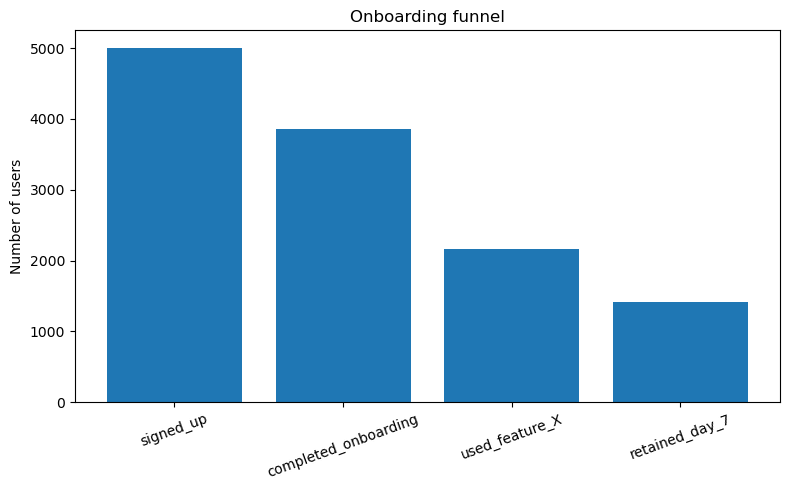

In [58]:
#plot it
plt.figure(figsize=(8,5))
plt.bar(funnel["stage"], funnel["users"])
plt.title("Onboarding funnel")
plt.ylabel("Number of users")
plt.xticks(rotation = 20)
plt.tight_layout()
plt.show()

In [59]:
# measure whether feature X is linked to retention
# this is the heart of the product insight
retention_by_feature = users.groupby("used_feature_X")["retained_day_7"].mean().reset_index()
retention_by_feature["retained_day_7"] = retention_by_feature["retained_day_7"].apply(pct)
retention_by_feature["used_feature_X"]=retention_by_feature["used_feature_X"].map({0:"No", 1:"Yes"})
print(retention_by_feature)

  used_feature_X  retained_day_7
0             No           19.77
1            Yes           39.81


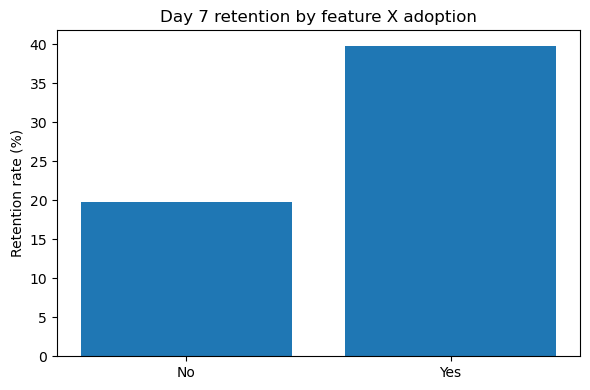

In [60]:
#plot it
plt.figure(figsize=(6,4))
plt.bar(retention_by_feature["used_feature_X"],retention_by_feature["retained_day_7"])
plt.title("Day 7 retention by feature X adoption")
plt.ylabel("Retention rate (%)")
plt.tight_layout()
plt.show()

In [61]:
#estimate the retention lift
retention_yes = users.loc[users["used_feature_X"]==1, "retained_day_7"].mean()
retention_no = users.loc[users["used_feature_X"]==0, "retained_day_7"].mean()
lift = retention_yes-retention_no
relative_lift = lift/retention_no if retention_no>0 else np.nan
print("Retention with feature X:", pct(retention_yes), "%")
print("Retention without feature X:", pct(retention_no), "%")
print("Absolute lift:", round(lift * 100,2), "percentage points")
print("Relative lift:", round(relative_lift *100,2), "%")

#Interpretation: If users who adopt feature_X retain much better, than suggests onboarding should encourage it.

Retention with feature X: 39.81 %
Retention without feature X: 19.77 %
Absolute lift: 20.03 percentage points
Relative lift: 101.3 %


In [68]:
# compare experiment groups
# Now lets see whether treatment increased adoption and retention
experiment_summary= users.groupby("experiment_group").agg({
    "used_feature_X":"mean",
    "retained_day_7":"mean",
    "sesisons_first_7d":"mean"
}).reset_index()
experiment_summary["used_feature_X"]=experiment_summary["used_feature_X"].apply(pct)
experiment_summary["retained_day_7"]=experiment_summary["retained_day_7"].apply(pct)
experiment_summary["sesisons_first_7d"]=experiment_summary["sesisons_first_7d"].round(2)
print(experiment_summary)

  experiment_group  used_feature_X  retained_day_7  sesisons_first_7d
0          control           36.89           26.87               3.91
1        treatment           49.47           29.96               4.05


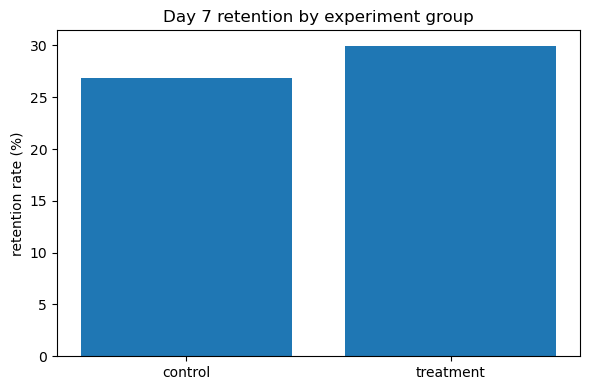

In [63]:
#plot treatment vs control retention
retention_plot=users.groupby("experiment_group")["retained_day_7"].mean().reset_index()
retention_plot["retained_day_7"]=retention_plot["retained_day_7"].apply(pct)
plt.figure(figsize=(6,4))
plt.bar(retention_plot["experiment_group"],retention_plot["retained_day_7"])
plt.title("Day 7 retention by experiment group")
plt.ylabel("retention rate (%)")
plt.tight_layout()
plt.show()

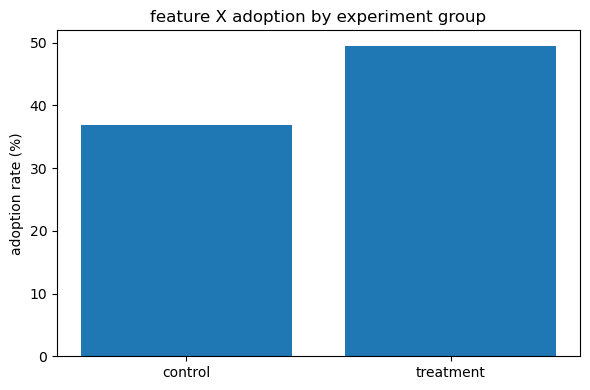

In [64]:
#plot feature adoption by group
adoption_plot = users.groupby("experiment_group")["used_feature_X"].mean().reset_index()
adoption_plot["used_feature_X"]=adoption_plot["used_feature_X"].apply(pct)
plt.figure(figsize=(6,4))
plt.bar(adoption_plot["experiment_group"],adoption_plot["used_feature_X"])
plt.title("feature X adoption by experiment group")
plt.ylabel("adoption rate (%)")
plt.tight_layout()
plt.show()

In [72]:
#Run a statistical significance test, we will use chi_square test on retention outcomes
contingency = pd.crosstab(users["experiment_group"],users["retained_day_7"])
print(contingency)
chi2,p_value,dof,expected=chi2_contingency(contingency)
print("chi_square statistic:",round(chi2,4))
print("p_value",round(p_value,6))

retained_day_7       0    1
experiment_group           
control           1804  663
treatment         1774  759
chi_square statistic: 5.7115
p_value 0.016854


In [73]:
#Decision rule
alpha = 0.05
if p_value < alpha:
    print("Result is statistically significant. Reject the null hypothesis.")
else:
    print("Result is not statistically significant fail to reject the null hypothesis.")

Result is statistically significant. Reject the null hypothesis.


In [76]:
#You can also test feature adoption significance
contingency_feature = pd.crosstab(users["experiment_group"],users["used_feature_X"])
chi2_f,p_value_f,dof_f,expected_f=chi2_contingency(contingency_feature)
print("feature adoption p_value:",round(p_value_f,6))

feature adoption p_value: 0.0


In [78]:
#write the final product recommendation
#this is the most important business step
#used code to generate a quick decision summary
control_retention=users.loc[users["experiment_group"]=="control", "retained_day_7"].mean()
treatment_retention = users.loc[users["experiment_group"]=="treatment","retained_day_7"].mean()
retention_diff = treatment_retention-control_retention
control_adoption=users.loc[users["experiment_group"]=="control","used_feature_X"].mean()
treatment_adoption=users.loc[users["experiment_group"]=="treatment","used_feature_X"].mean()
adoption_diff = treatment_adoption-control_adoption
print(f"control_retention:{pct(control_retention)}%")
print(f"treatment_retention:{pct(treatment_retention)}%")
print(f"retention_lift:{round(retention_diff*100,2)}percentage points")
print()
print(f"control feature adoption:{pct(control_adoption)}%")
print(f"treatment feature adoption:{pct(treatment_adoption)}%")
print(f"adoption lift:{round(adoption_diff*100,2)}percentage points")
print()
print(f"Retention p_value:{round(p_value,6)}")

control_retention:26.87%
treatment_retention:29.96%
retention_lift:3.09percentage points

control feature adoption:36.89%
treatment feature adoption:49.47%
adoption lift:12.58percentage points

Retention p_value:0.016854


In [79]:
#Business recommendation tempelate
if p_value < 0.05 and retention_diff > 0:
    recommendation = """
    Roll out the treatment onboarding experience to all new users
    Reason:
    The increment significantly improved early feature adoption and increases Day 7 retention.
    This suggests that highlighting feature X during onboarding creates a better first-session experience and helps users reach faster.
    """
else:
    recommendation = """
    Recommendation:
    Do not roll out yet.
    Reason:
    The observed retention improvement was not statistically strong enough.
    Consider iterating on the onboarding intervention and rerunning the experiment.
    """
print(recommendation)


    Roll out the treatment onboarding experience to all new users
    Reason:
    The increment significantly improved early feature adoption and increases Day 7 retention.
    This suggests that highlighting feature X during onboarding creates a better first-session experience and helps users reach faster.
    


In [85]:
#Create a clean summary table for your portfolio
summary = pd.DataFrame({
    "Metric":[
    "Onboarding Completion Rate",
    "Feature X Adoption Rate",
    "Day 7 Retention Rate",
    "Average Sessions(First 7 Days)"
    ],
    "Control":[
      pct(users.loc[users["experiment_group"]=="control","completed_onboarding"].mean()),
      pct(users.loc[users["experiment_group"]=="control","used_feature_X"].mean()),
      pct(users.loc[users["experiment_group"]=="control","retained_day_7"].mean()),
      round(users.loc[users["experiment_group"]=="control","sesisons_first_7d"].mean(),2),   
    ],
    "Treatment":[
      pct(users.loc[users["experiment_group"]=="treatment","completed_onboarding"].mean()),
      pct(users.loc[users["experiment_group"]=="treatment","used_feature_X"].mean()),
      pct(users.loc[users["experiment_group"]=="treatment","retained_day_7"].mean()),
      round(users.loc[users["experiment_group"]=="treatment","sesisons_first_7d"].mean(),2),
    ]
})
print(summary)

                           Metric  Control  Treatment
0      Onboarding Completion Rate    77.67      76.87
1         Feature X Adoption Rate    36.89      49.47
2            Day 7 Retention Rate    26.87      29.96
3  Average Sessions(First 7 Days)     3.91       4.05
